###Question 1: SVM for Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

Load Dataset

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

Train/Test Split + Standardize

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Hard Margin SVM

In [4]:
hard_svm = SVC(kernel='linear', C=1e6, probability=True)
hard_svm.fit(X_train, y_train)

SVC(C=1000000.0, kernel='linear', probability=True)

Soft Margin SVM with 5-Fold CV

In [5]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    SVC(kernel='linear', probability=True),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

best_svm = grid.best_estimator_
print("Best C:", grid.best_params_['C'])

Best C: 0.1


Logistic Regression Baseline

In [6]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

Evaluation Metrics

In [7]:
models = {
    "Hard SVM": hard_svm,
    "Soft SVM": best_svm,
    "Logistic Regression": lr
}

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("F1 Score:", round(f1_score(y_test, pred), 4))
    print("ROC AUC:", round(roc_auc_score(y_test, prob), 4))


Hard SVM
Accuracy: 0.9298
F1 Score: 0.9429
ROC AUC: 0.9775

Soft SVM
Accuracy: 0.9825
F1 Score: 0.9861
ROC AUC: 0.9937

Logistic Regression
Accuracy: 0.9825
F1 Score: 0.9861
ROC AUC: 0.9954


PCA to 2D for Visualization

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

svm_2d = SVC(kernel='linear', C=grid.best_params_['C'])
svm_2d.fit(X_pca, y_train)

SVC(C=0.1, kernel='linear')

Plot Decision Boundary + Margin + Support Vectors

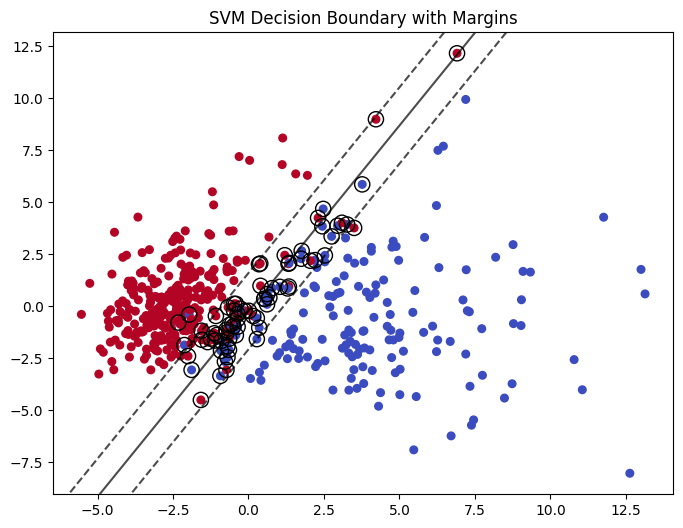

In [9]:
def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(8,6))

    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=30)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(
        XX, YY, Z,
        colors='k',
        levels=[-1, 0, 1],
        alpha=0.7,
        linestyles=['--', '-', '--']
    )

    ax.scatter(
        model.support_vectors_[:,0],
        model.support_vectors_[:,1],
        s=120,
        facecolors='none',
        edgecolors='black'
    )

    plt.title("SVM Decision Boundary with Margins")
    plt.show()

plot_svm_boundary(svm_2d, X_pca, y_train)

Support Vector / Margin Analysis Table

In [10]:
w = svm_2d.coef_[0]
margin = 2 / np.linalg.norm(w)

results = pd.DataFrame({
    "Best C": [grid.best_params_['C']],
    "Num Support Vectors": [len(svm_2d.support_)],
    "Margin Width": [margin],
    "Test Accuracy": [accuracy_score(y_test, best_svm.predict(X_test))]
})

results

,Best C,Num Support Vectors,Margin Width,Test Accuracy
0,0.1,74,1.794546,0.982456


In [11]:
print("Dual Coefficients Shape:", best_svm.dual_coef_.shape)
print("Number of Support Vectors:", len(best_svm.support_))
print("Non-support vectors implicitly have alpha = 0")

Dual Coefficients Shape: (1, 51)
Number of Support Vectors: 51
Non-support vectors implicitly have alpha = 0


ROC Curve Comparison

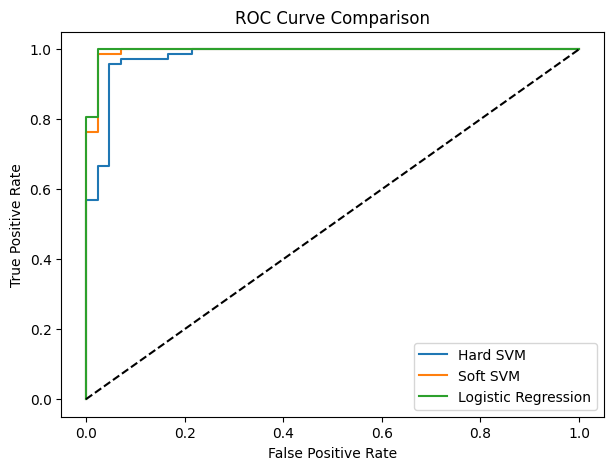

In [12]:
plt.figure(figsize=(7,5))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

###Part B: Kernel SVM for Digit Recognition

In [13]:
import time
from sklearn.datasets import load_digits

In [14]:
digits = load_digits()
X = digits.data
y = digits.target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Linear, Polynomial, RBF SVM

In [16]:
kernels = {
    "Linear": SVC(kernel='linear'),
    "Polynomial": SVC(kernel='poly', degree=3),
    "RBF": SVC(kernel='rbf')
}

results = []

for name, model in kernels.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    acc = accuracy_score(y_test, model.predict(X_test))

    results.append([
        name,
        acc,
        len(model.support_),
        train_time
    ])

kernel_results = pd.DataFrame(
    results,
    columns=["Kernel", "Accuracy", "Num Support Vectors", "Training Time"]
)

kernel_results

,Kernel,Accuracy,Num Support Vectors,Training Time
0,Linear,0.975000,429,0.036429
1,Polynomial,0.972222,810,0.077243
2,RBF,0.975000,746,0.060041


Tune RBF Hyperparameters

In [17]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1]
}

grid_rbf = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5
)

grid_rbf.fit(X_train, y_train)

best_rbf = grid_rbf.best_estimator_

print("Best Params:", grid_rbf.best_params_)
print("Best CV Score:", grid_rbf.best_score_)

Best Params: {'C': 10, 'gamma': 0.01}
Best CV Score: 0.9826050135501354


Evaluate Best RBF

In [18]:
pred = best_rbf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred))
print("Support Vectors:", len(best_rbf.support_))

Test Accuracy: 0.9833333333333333
Support Vectors: 650


Visualize Top Support Vector Images

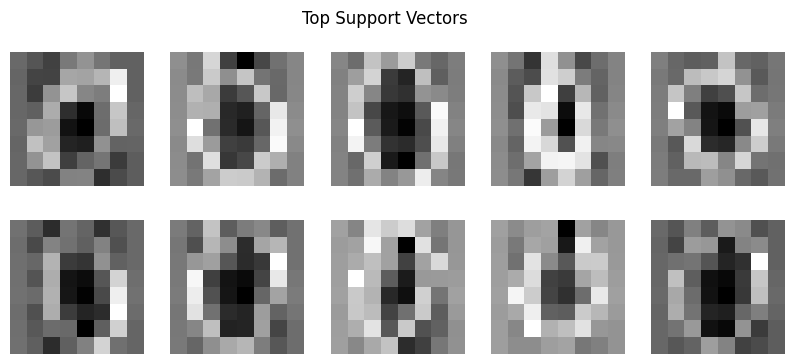

In [19]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(best_rbf.support_vectors_[i].reshape(8,8), cmap='gray')
    plt.axis('off')

plt.suptitle("Top Support Vectors")
plt.show()

Dual Sparsity Bar Plot

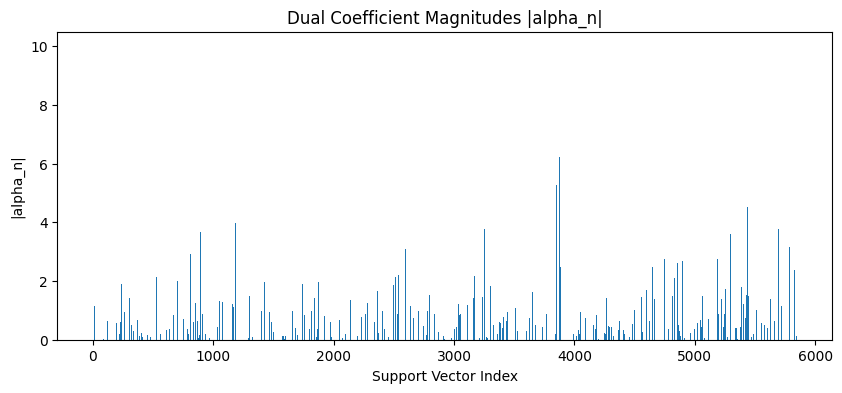

In [20]:
alpha_vals = np.abs(best_rbf.dual_coef_).flatten()

plt.figure(figsize=(10,4))
plt.bar(range(len(alpha_vals)), alpha_vals)
plt.title("Dual Coefficient Magnitudes |alpha_n|")
plt.xlabel("Support Vector Index")
plt.ylabel("|alpha_n|")
plt.show()

Training Time vs Sample Size

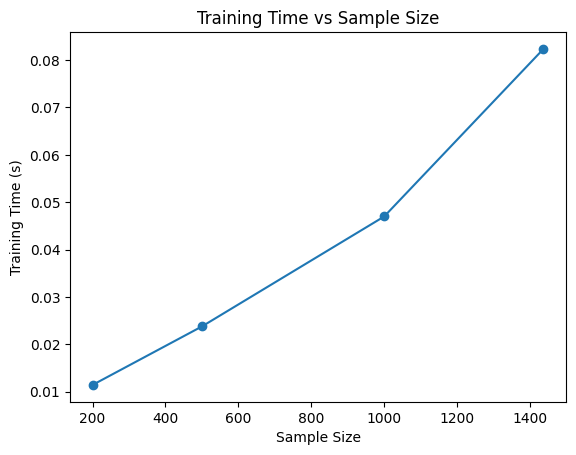

In [21]:
sample_sizes = [200, 500, 1000, len(X_train)]
times = []

for n in sample_sizes:
    start = time.time()

    model = SVC(kernel='rbf', C=best_rbf.C, gamma=best_rbf.gamma)
    model.fit(X_train[:n], y_train[:n])

    times.append(time.time() - start)

plt.plot(sample_sizes, times, marker='o')
plt.xlabel("Sample Size")
plt.ylabel("Training Time (s)")
plt.title("Training Time vs Sample Size")
plt.show()

###Question 2: Bayesian Linear Regression for House Price Prediction

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    BayesianRidge
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import shapiro, probplot

In [23]:
data = fetch_california_housing()

X = data.data
y = data.target

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Bayesian Ridge Regression

In [25]:
bayes = BayesianRidge()
bayes.fit(X_train, y_train)

BayesianRidge()

In [26]:
y_pred, y_std = bayes.predict(X_test, return_std=True)

Plot Predictive Mean

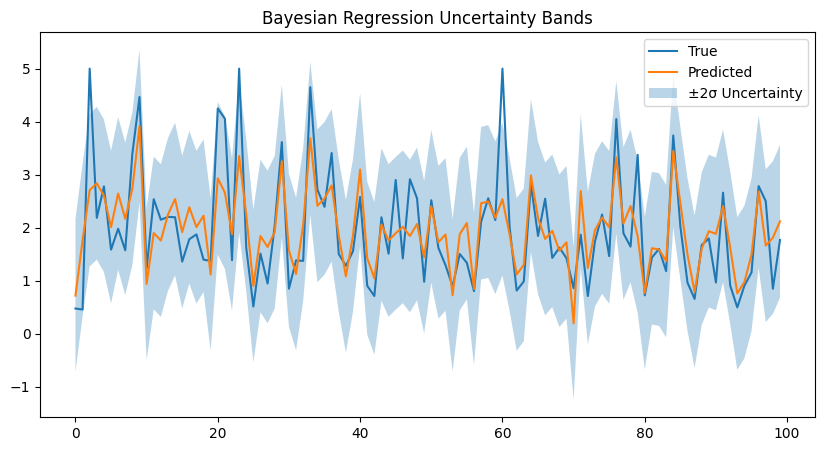

In [27]:
idx = np.arange(100)

plt.figure(figsize=(10,5))
plt.plot(idx, y_test[:100], label='True')
plt.plot(idx, y_pred[:100], label='Predicted')

plt.fill_between(
    idx,
    y_pred[:100] - 2*y_std[:100],
    y_pred[:100] + 2*y_std[:100],
    alpha=0.3,
    label='±2σ Uncertainty'
)

plt.legend()
plt.title("Bayesian Regression Uncertainty Bands")
plt.show()

Vary Prior Precision

In [28]:
alphas = [1e-6, 1e-3, 1, 1e3]

for a in alphas:
    model = BayesianRidge(alpha_1=a)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(f"Alpha={a}, RMSE={rmse:.4f}")

Alpha=1e-06, RMSE=0.7455
Alpha=0.001, RMSE=0.7455
Alpha=1, RMSE=0.7455
Alpha=1000.0, RMSE=0.7455


Compare with OLS and Ridge

In [29]:
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Bayesian Ridge": BayesianRidge()
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )

    rmse = np.sqrt(-scores.mean())

    cv_results.append([name, rmse])

cv_table = pd.DataFrame(cv_results, columns=["Model", "CV RMSE"])
cv_table

,Model,CV RMSE
0,OLS,0.720858
1,Ridge,0.720857
2,Bayesian Ridge,0.720857


Final Evaluation Metrics

In [30]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(f"\n{name}")
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)),4))
    print("MAE :", round(mean_absolute_error(y_test, pred),4))
    print("R²  :", round(r2_score(y_test, pred),4))


OLS
RMSE: 0.7456
MAE : 0.5332
R²  : 0.5758

Ridge
RMSE: 0.7456
MAE : 0.5332
R²  : 0.5758

Bayesian Ridge
RMSE: 0.7455
MAE : 0.5332
R²  : 0.5758


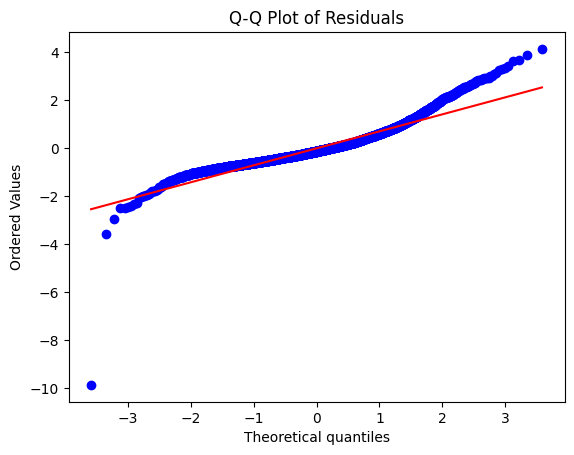

In [31]:
residuals = y_test - y_pred

probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Shapiro-Wilk Normality Test

In [32]:
stat, p = shapiro(residuals[:5000])  # limit sample size

print("Shapiro-Wilk Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Residuals appear normally distributed")
else:
    print("Residuals are NOT normally distributed")

Shapiro-Wilk Statistic: 0.9021869094130154
p-value: 1.7519462188329723e-45
Residuals are NOT normally distributed


###Question 3: Ridge and Lasso Regression for Polynomial Curve Fitting

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_score

Generate Synthetic Dataset

In [34]:
np.random.seed(42)

N = 20
N_test = 100

x_train = np.sort(np.random.rand(N))
t_train = np.sin(2*np.pi*x_train) + np.random.normal(0, 0.3, N)

x_test = np.linspace(0, 1, N_test)
t_test = np.sin(2*np.pi*x_test)

OLS Polynomial Fits for M = 1,3,6,9

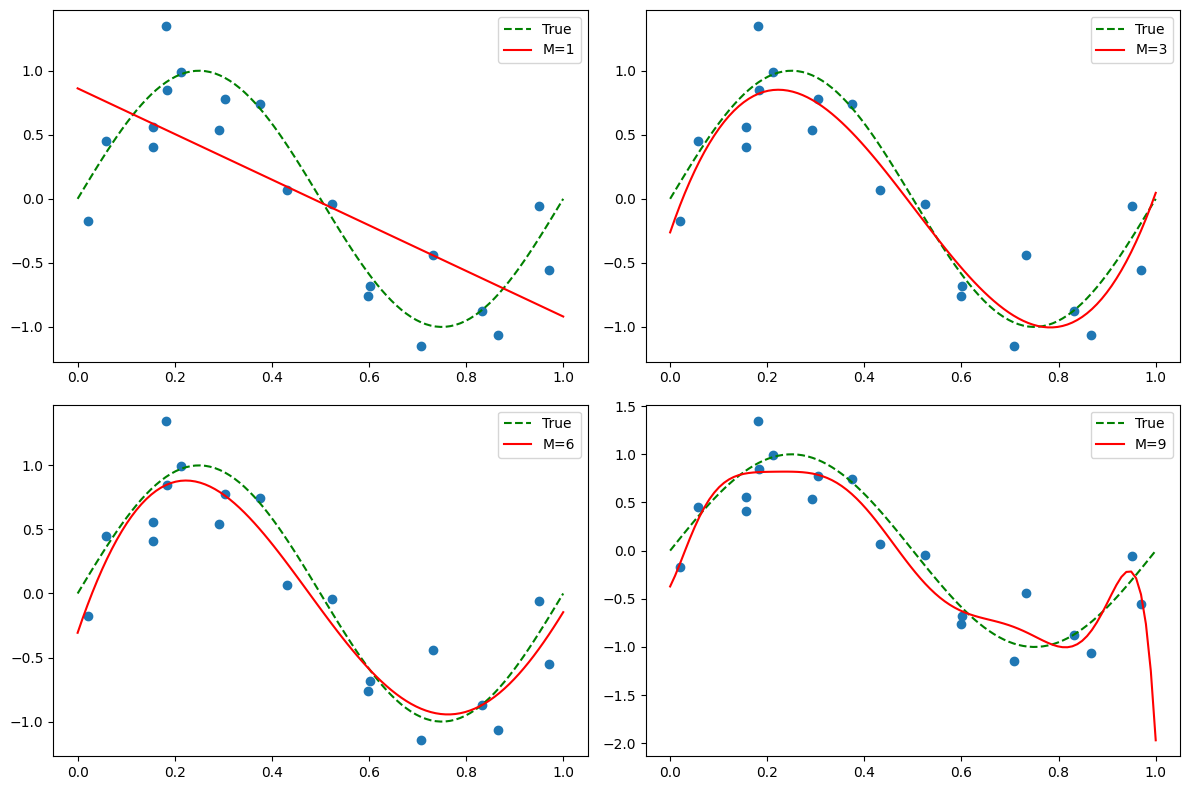

In [35]:
degrees = [1, 3, 6, 9]

plt.figure(figsize=(12,8))

for i, M in enumerate(degrees):
    poly = PolynomialFeatures(M)
    Xtr = poly.fit_transform(x_train.reshape(-1,1))
    Xte = poly.transform(x_test.reshape(-1,1))

    model = LinearRegression()
    model.fit(Xtr, t_train)

    pred = model.predict(Xte)

    plt.subplot(2,2,i+1)
    plt.scatter(x_train, t_train)
    plt.plot(x_test, t_test, 'g--', label='True')
    plt.plot(x_test, pred, 'r', label=f'M={M}')
    plt.legend()

plt.tight_layout()
plt.show()

Ridge Regression for Different λ

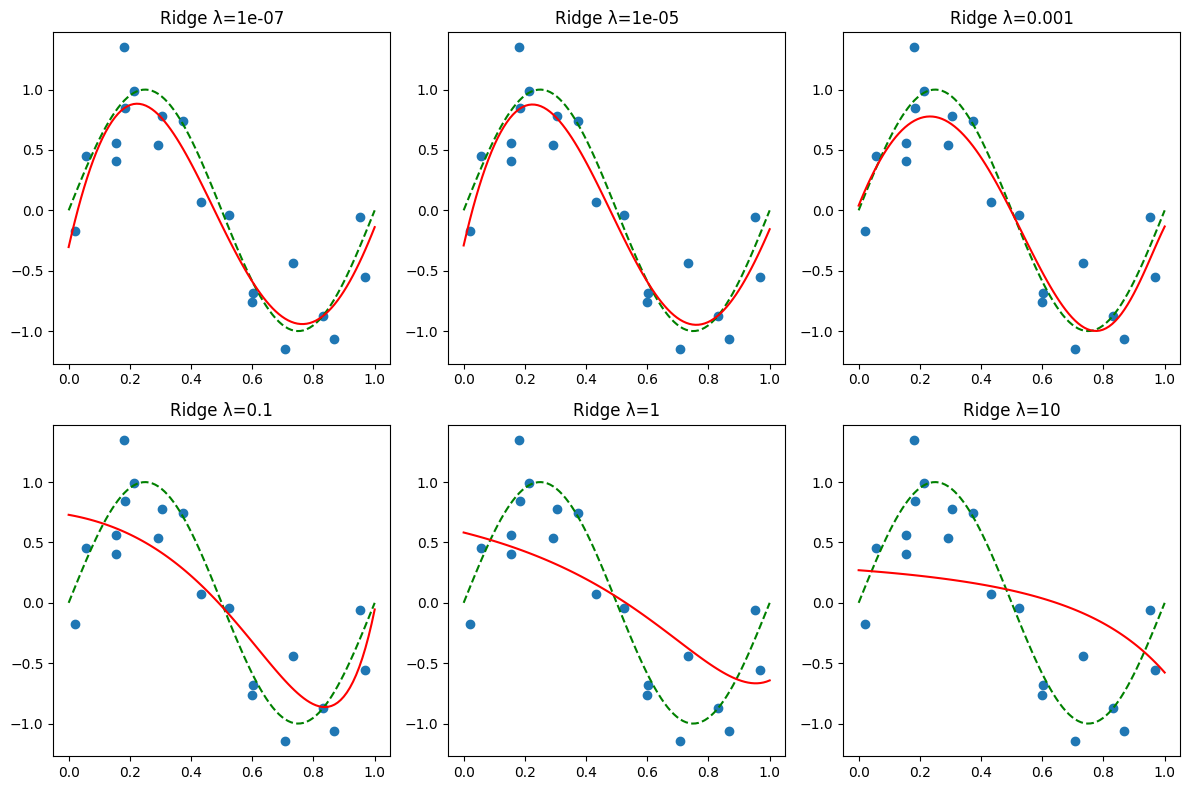

In [36]:
lambdas = [1e-7, 1e-5, 1e-3, 1e-1, 1, 10]

poly = PolynomialFeatures(9)
Xtr = poly.fit_transform(x_train.reshape(-1,1))
Xte = poly.transform(x_test.reshape(-1,1))

plt.figure(figsize=(12,8))

ridge_rmse = []

for i, lam in enumerate(lambdas):
    model = Ridge(alpha=lam)
    model.fit(Xtr, t_train)

    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(t_test, pred))
    ridge_rmse.append(rmse)

    plt.subplot(2,3,i+1)
    plt.scatter(x_train, t_train)
    plt.plot(x_test, t_test, 'g--')
    plt.plot(x_test, pred, 'r')
    plt.title(f'Ridge λ={lam}')

plt.tight_layout()
plt.show()

Lasso Regression for Different λ

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.505e-01, tolerance: 1.039e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.672e-01, tolerance: 1.039e-03
  model = cd_fast.enet_coordinate_descent(


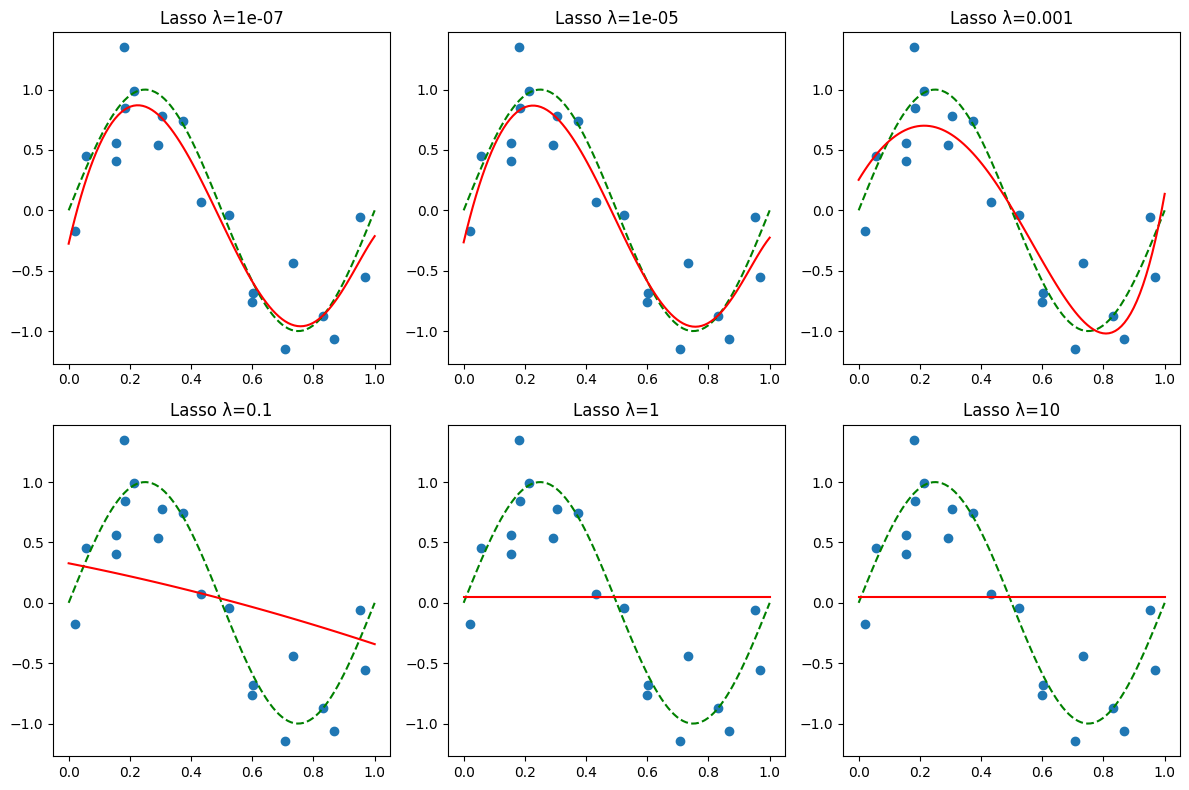

In [37]:
plt.figure(figsize=(12,8))

lasso_rmse = []

for i, lam in enumerate(lambdas):
    model = Lasso(alpha=lam, max_iter=10000)
    model.fit(Xtr, t_train)

    pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(t_test, pred))
    lasso_rmse.append(rmse)

    plt.subplot(2,3,i+1)
    plt.scatter(x_train, t_train)
    plt.plot(x_test, t_test, 'g--')
    plt.plot(x_test, pred, 'r')
    plt.title(f'Lasso λ={lam}')

plt.tight_layout()
plt.show()

Compare Coefficients

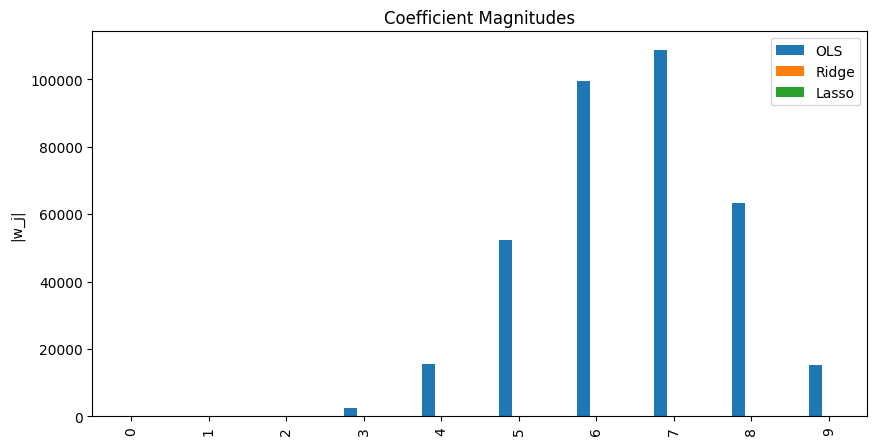

In [38]:
ols = LinearRegression().fit(Xtr, t_train)
ridge = Ridge(alpha=0.1).fit(Xtr, t_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(Xtr, t_train)

coef_df = pd.DataFrame({
    'OLS': np.abs(ols.coef_),
    'Ridge': np.abs(ridge.coef_),
    'Lasso': np.abs(lasso.coef_)
})

coef_df.plot(kind='bar', figsize=(10,5))
plt.title("Coefficient Magnitudes")
plt.ylabel("|w_j|")
plt.show()

RMSE Table

In [39]:
rmse_table = pd.DataFrame({
    'Lambda': lambdas,
    'Ridge RMSE': ridge_rmse,
    'Lasso RMSE': lasso_rmse
})

rmse_table

,Lambda,Ridge RMSE,Lasso RMSE
0,1.000000e-07,0.120065,0.113377
1,1.000000e-05,0.116202,0.111923
2,1.000000e-03,0.118877,0.179407
3,1.000000e-01,0.316972,0.568091
4,1.000000e+00,0.439715,0.705142
5,1.000000e+01,0.580259,0.705142


LOOCV for Optimal λ

In [40]:
loo = LeaveOneOut()

ridge_cv = []
lasso_cv = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    lasso = Lasso(alpha=lam, max_iter=10000)

    ridge_score = -cross_val_score(
        ridge, Xtr, t_train,
        cv=loo,
        scoring='neg_mean_squared_error'
    ).mean()

    lasso_score = -cross_val_score(
        lasso, Xtr, t_train,
        cv=loo,
        scoring='neg_mean_squared_error'
    ).mean()

    ridge_cv.append(ridge_score)
    lasso_cv.append(lasso_score)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.272e-01, tolerance: 1.034e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.232e-01, tolerance: 1.022e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.228e-01, tolerance: 1.012e

Plot LOOCV Error vs log(λ)

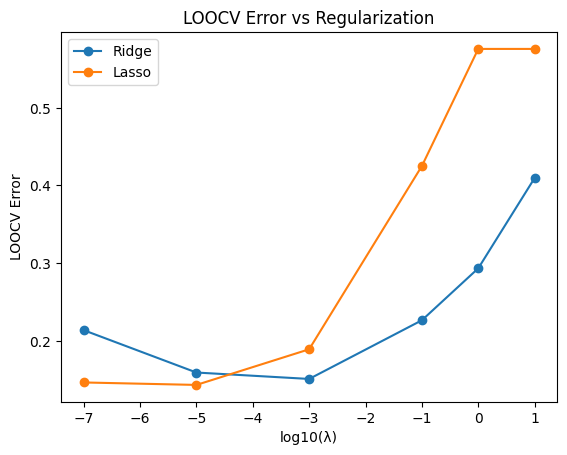

In [41]:
plt.plot(np.log10(lambdas), ridge_cv, marker='o', label='Ridge')
plt.plot(np.log10(lambdas), lasso_cv, marker='o', label='Lasso')

plt.xlabel('log10(λ)')
plt.ylabel('LOOCV Error')
plt.title('LOOCV Error vs Regularization')
plt.legend()
plt.show()

###Question 4: SVM for Imbalanced Classification

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

Generate Imbalanced Fraud-like Dataset

In [43]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[0.99, 0.01],
    random_state=42
)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train Weighted RBF SVM

In [45]:
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True
)

svm.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True)

Precision-Recall Curve + AUPRC

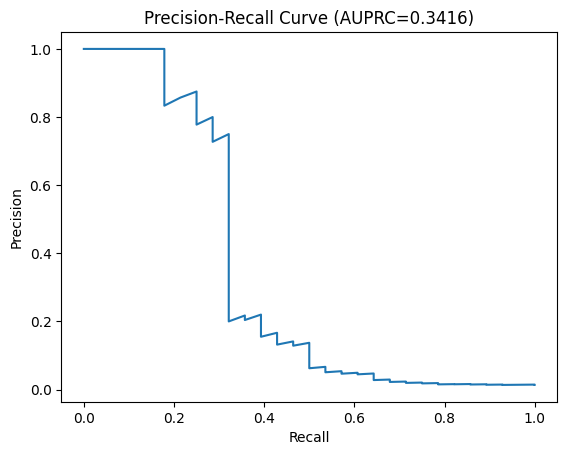

In [46]:
probs = svm.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, probs)
auprc = average_precision_score(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUPRC={auprc:.4f})")
plt.show()

Analyze Different Class Weight Ratios

In [47]:
ratios = [1, 5, 10, 20, 50]

precisions = []
recalls = []
f1s = []

for r in ratios:
    model = SVC(
        kernel='rbf',
        class_weight={0:1, 1:r}
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    precisions.append(precision_score(y_test, pred))
    recalls.append(recall_score(y_test, pred))
    f1s.append(f1_score(y_test, pred))

Plot Precision / Recall / F1 vs Weight Ratio

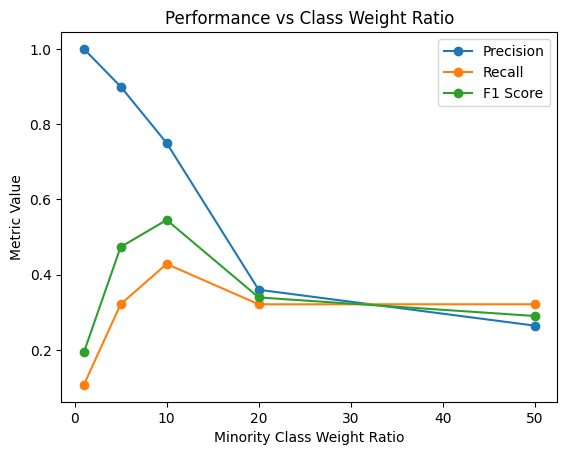

In [48]:
plt.plot(ratios, precisions, marker='o', label='Precision')
plt.plot(ratios, recalls, marker='o', label='Recall')
plt.plot(ratios, f1s, marker='o', label='F1 Score')

plt.xlabel("Minority Class Weight Ratio")
plt.ylabel("Metric Value")
plt.title("Performance vs Class Weight Ratio")
plt.legend()
plt.show()

Results Table

In [49]:
results = pd.DataFrame({
    'Weight Ratio': ratios,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1s
})

results

,Weight Ratio,Precision,Recall,F1 Score
0,1,1.000000,0.107143,0.193548
1,5,0.900000,0.321429,0.473684
2,10,0.750000,0.428571,0.545455
3,20,0.360000,0.321429,0.339623
4,50,0.264706,0.321429,0.290323


###Question 5: Kernel Density Estimation

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV

In [54]:
faithful = fetch_openml(data_id=18, as_frame=True)

data = faithful.data
X = data.values
eruption = X[:, 0].reshape(-1,1)

1D KDE for Different Bandwidths

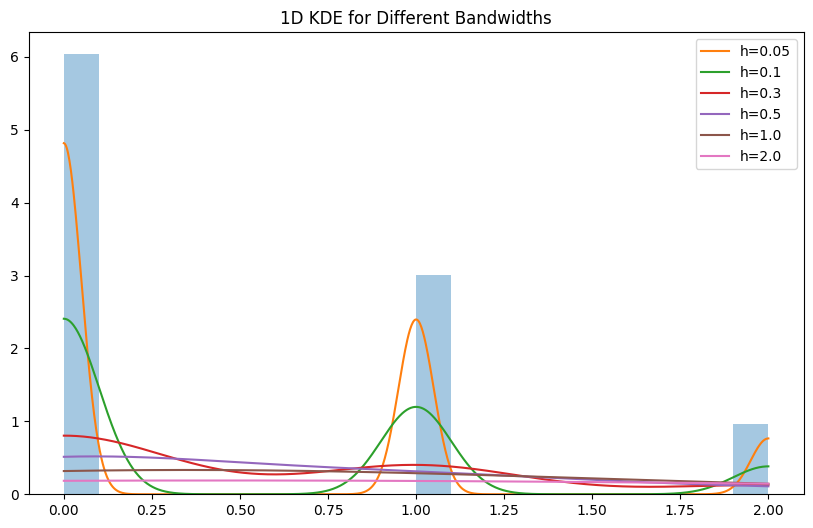

In [55]:
bandwidths = [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]

x_plot = np.linspace(eruption.min(), eruption.max(), 1000).reshape(-1,1)

plt.figure(figsize=(10,6))
plt.hist(eruption, bins=20, density=True, alpha=0.4)

for h in bandwidths:
    kde = KernelDensity(kernel='gaussian', bandwidth=h)
    kde.fit(eruption)

    log_dens = kde.score_samples(x_plot)
    plt.plot(x_plot, np.exp(log_dens), label=f'h={h}')

plt.legend()
plt.title("1D KDE for Different Bandwidths")
plt.show()

Compare Kernel Shapes

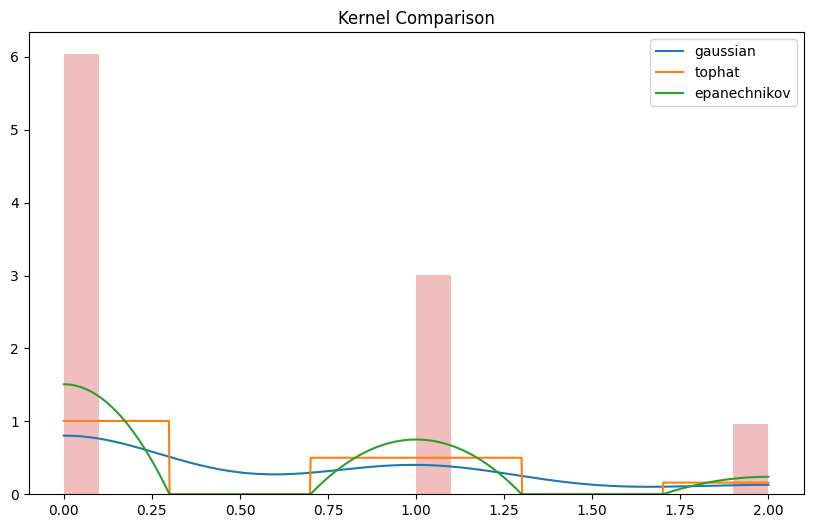

In [56]:
kernels = ['gaussian', 'tophat', 'epanechnikov']

plt.figure(figsize=(10,6))

for kernel in kernels:
    kde = KernelDensity(kernel=kernel, bandwidth=0.3)
    kde.fit(eruption)

    log_dens = kde.score_samples(x_plot)
    plt.plot(x_plot, np.exp(log_dens), label=kernel)

plt.hist(eruption, bins=20, density=True, alpha=0.3)
plt.legend()
plt.title("Kernel Comparison")
plt.show()

2D KDE Contour Plot

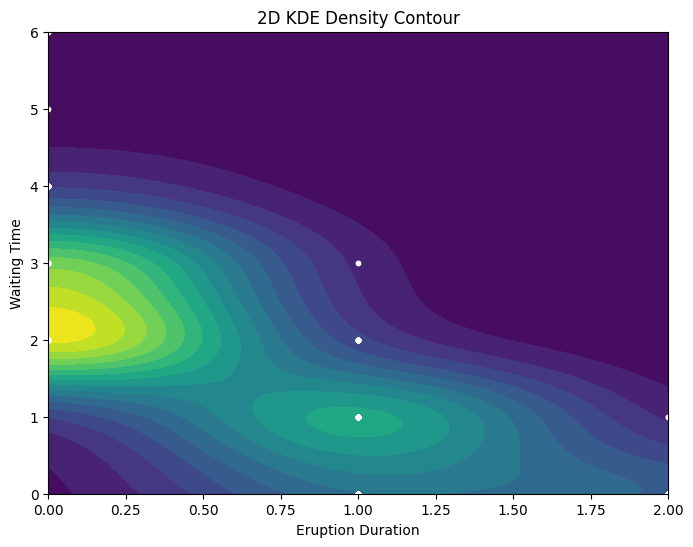

In [58]:
kde2d = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde2d.fit(X[:, :2])

xgrid = np.linspace(X[:,0].min(), X[:,0].max(), 100)
ygrid = np.linspace(X[:,1].min(), X[:,1].max(), 100)

xx, yy = np.meshgrid(xgrid, ygrid)
grid = np.vstack([xx.ravel(), yy.ravel()]).T

z = np.exp(kde2d.score_samples(grid)).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, z, levels=20, cmap='viridis')
plt.scatter(X[:,0], X[:,1], s=10, c='white')
plt.title("2D KDE Density Contour")
plt.xlabel("Eruption Duration")
plt.ylabel("Waiting Time")
plt.show()

KDE vs GMM Comparison

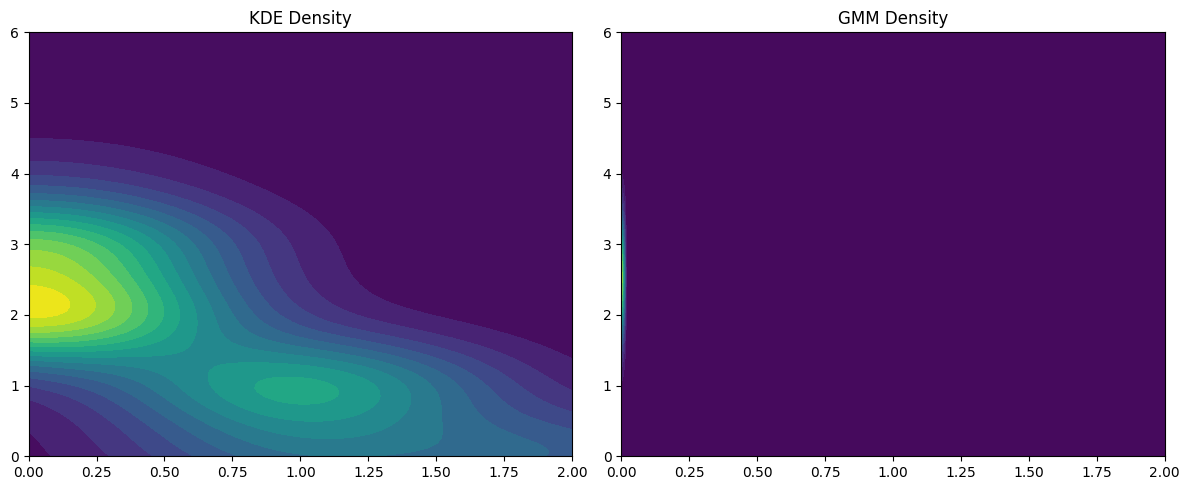

In [60]:
gmm = GaussianMixture(n_components=2)
gmm.fit(X[:, :2])

kde_density = np.exp(kde2d.score_samples(grid))
gmm_density = np.exp(gmm.score_samples(grid))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.contourf(xx, yy, kde_density.reshape(xx.shape), levels=20)
plt.title("KDE Density")

plt.subplot(1,2,2)
plt.contourf(xx, yy, gmm_density.reshape(xx.shape), levels=20)
plt.title("GMM Density")

plt.tight_layout()
plt.show()

Cross-Validated Bandwidth Selection

In [61]:
params = {'bandwidth': bandwidths}

grid_search = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    params,
    cv=5
)

grid_search.fit(eruption)

print("Best Bandwidth:", grid_search.best_params_['bandwidth'])
print("Best CV Log-Likelihood:", grid_search.best_score_)

Best Bandwidth: 0.3
Best CV Log-Likelihood: -463.3109136095997


Plot CV Log-Likelihood vs Bandwidth

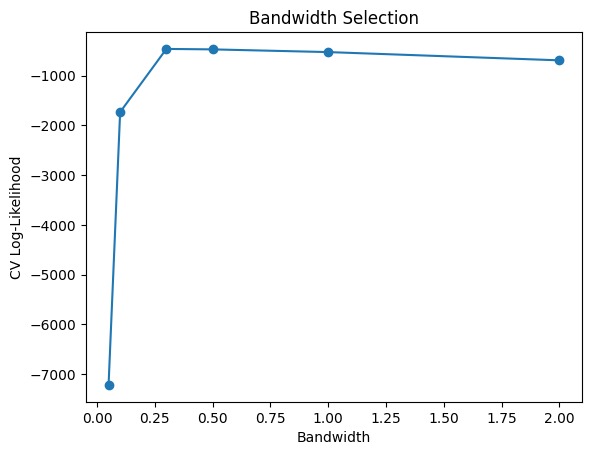

In [62]:
scores = grid_search.cv_results_['mean_test_score']

plt.plot(bandwidths, scores, marker='o')
plt.xlabel("Bandwidth")
plt.ylabel("CV Log-Likelihood")
plt.title("Bandwidth Selection")
plt.show()

###Question 6: K-Nearest Neighbours for Classification and Density Estimation

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.svm import SVC

In [64]:
iris = load_iris()
X = iris.data
y = iris.target

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Cross-Validated Accuracy vs K

In [66]:
K_values = [1, 3, 5, 7, 11, 15, 25]

cv_acc = []

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10)
    cv_acc.append(scores.mean())

Plot Accuracy vs K

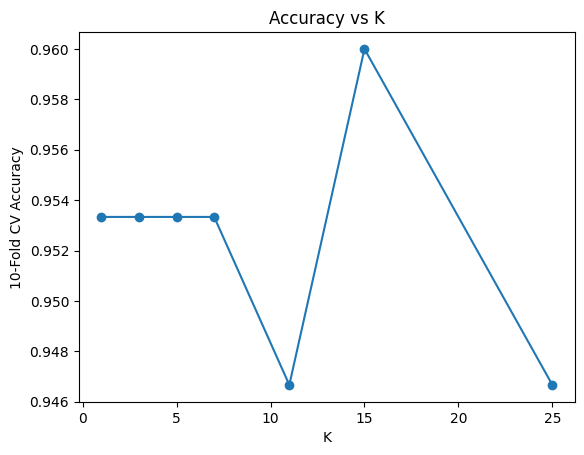

In [67]:
plt.plot(K_values, cv_acc, marker='o')
plt.xlabel("K")
plt.ylabel("10-Fold CV Accuracy")
plt.title("Accuracy vs K")
plt.show()

Decision Boundaries for K = 1,5,15

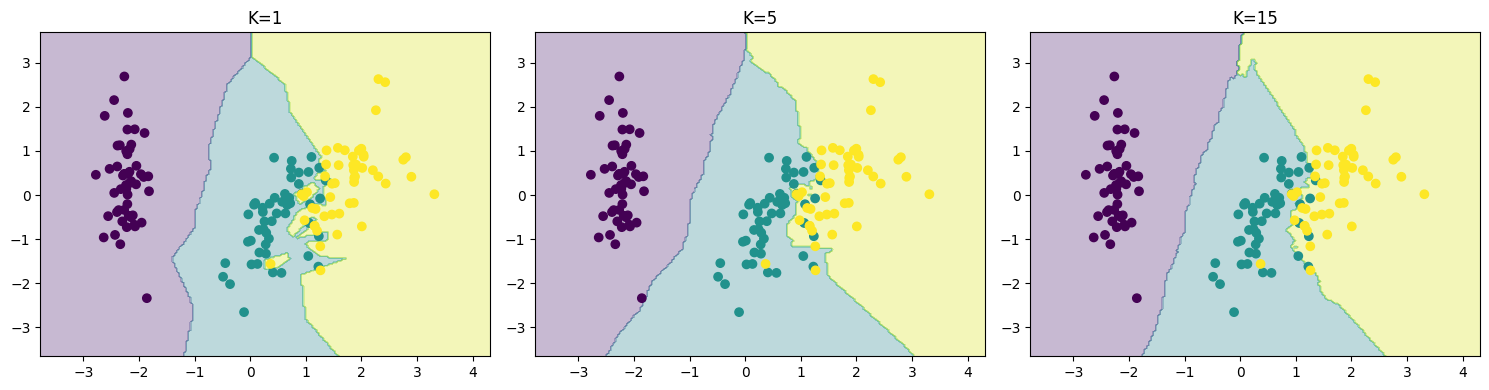

In [68]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Ks = [1, 5, 15]

plt.figure(figsize=(15,4))

for i, k in enumerate(Ks):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_pca, y)

    x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
    y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1,3,i+1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
    plt.title(f"K={k}")

plt.tight_layout()
plt.show()

In [69]:
X_syn, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

KNN Density Estimate vs KDE

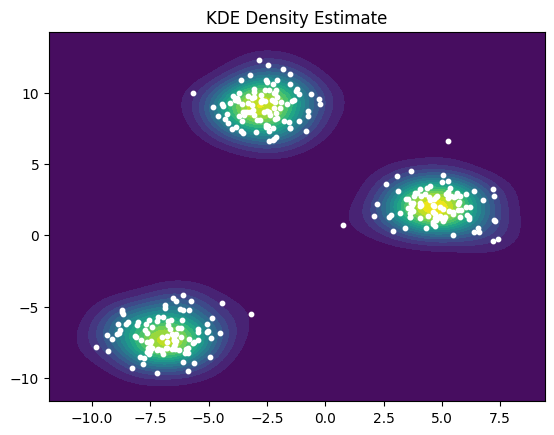

In [70]:
kde = KernelDensity(bandwidth=1.0)
kde.fit(X_syn)

xgrid = np.linspace(X_syn[:,0].min()-2, X_syn[:,0].max()+2, 100)
ygrid = np.linspace(X_syn[:,1].min()-2, X_syn[:,1].max()+2, 100)

xx, yy = np.meshgrid(xgrid, ygrid)
grid = np.vstack([xx.ravel(), yy.ravel()]).T

density = np.exp(kde.score_samples(grid)).reshape(xx.shape)

plt.contourf(xx, yy, density, levels=20)
plt.scatter(X_syn[:,0], X_syn[:,1], s=10, c='white')
plt.title("KDE Density Estimate")
plt.show()

Distance Metric Comparison

In [71]:
metrics = ['euclidean', 'manhattan']

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    scores = cross_val_score(knn, X_scaled, y, cv=10)

    print(f"{metric}: {scores.mean():.4f}")

euclidean: 0.9533
manhattan: 0.9467


Compare KNN vs SVM

In [72]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf')

knn_score = cross_val_score(knn, X_scaled, y, cv=10).mean()
svm_score = cross_val_score(svm, X_scaled, y, cv=10).mean()

comparison = pd.DataFrame({
    'Model': ['KNN', 'SVM (RBF)'],
    'CV Accuracy': [knn_score, svm_score]
})

comparison

,Model,CV Accuracy
0,KNN,0.953333
1,SVM (RBF),0.966667
